In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import re


In [34]:
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.layers import Dense


In [35]:
df = pd.read_csv(
    r"C:\Users\HP\Downloads\IMDB Dataset.csv",
    encoding="latin-1",
    engine="python",
    on_bad_lines="skip"
)

print("Dataset Loaded Successfully")
print(df.head())


Dataset Loaded Successfully
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [36]:
df = df.dropna()

In [37]:
# =========================================
def clean_text(text):

    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z ]', '', text)

    return text


df['review'] = df['review'].apply(clean_text)


In [38]:
# =========================================
# 5. CONVERT LABELS
# positive -> 1
# negative -> 0
# =========================================
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

print(df['sentiment'].value_counts())



sentiment
0    24813
1    24799
Name: count, dtype: int64


In [39]:
# =========================================
# 6. TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    df['review'],
    df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [40]:
# =========================================
# 7. TOKENIZATION
# Convert words into sequences
# =========================================
tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(X_train)

X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)


In [41]:
# =========================================
# 8. PADDING
# Make all reviews same length
# =========================================
X_train = pad_sequences(X_train, maxlen=200)
X_test = pad_sequences(X_test, maxlen=200)

In [42]:
model = Sequential([

    # Embedding Layer
    Embedding(10000, 32),

    # Pooling Layer
    GlobalAveragePooling1D(),

    # Hidden Layer
    Dense(32, activation='relu'),

    # Output Layer
    Dense(1, activation='sigmoid')
])

In [43]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [44]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [45]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)



Epoch 1/5
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8097 - loss: 0.4171 - val_accuracy: 0.8774 - val_loss: 0.2969
Epoch 2/5
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.8919 - loss: 0.2619 - val_accuracy: 0.8645 - val_loss: 0.3201
Epoch 3/5
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9058 - loss: 0.2325 - val_accuracy: 0.8797 - val_loss: 0.2922
Epoch 4/5
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9126 - loss: 0.2156 - val_accuracy: 0.8819 - val_loss: 0.2917
Epoch 5/5
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9224 - loss: 0.1950 - val_accuracy: 0.8794 - val_loss: 0.2997


In [46]:
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)

311/311 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8794 - loss: 0.2997

Test Accuracy: 0.879371166229248


In [47]:
predictions = model.predict(X_test[:5])

print("\nPredictions:")
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step

Predictions:
[[0.91173655]
 [0.28192276]
 [0.00378517]
 [0.97339725]
 [0.23782699]]


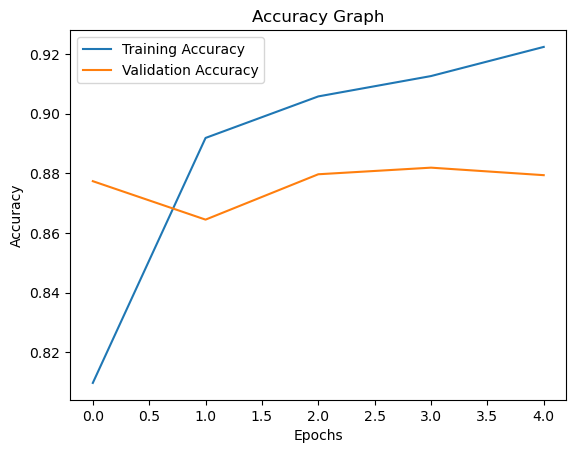

In [48]:
plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()